In [1]:
pip install nest_asyncio



[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pyppeteer


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import os
import operator
import nest_asyncio
nest_asyncio.apply()


load_dotenv()

True

In [4]:
model= ChatOpenAI(api_key=os.getenv("api_key"), temperature=0,model="gpt-4o-mini")

In [5]:
# For structured output
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="The sentiment of the review")


In [6]:

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [7]:
structured_model=model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [8]:
prompt=f"what is the sentiment of the following review? Respond with positive or negative only.\n\nReview: The software is too bad."

structured_model.invoke(prompt)


SentimentSchema(sentiment='negative')

In [9]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [10]:
def find_sentiment(state: ReviewState):

    prompt=f"For the following review, determine if the sentiment is positive or negative. \n\nReview: {state['review']}"

    sentiment=structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}


def check_sentiment(state: ReviewState)-> Literal['positive_response', 'run_diagnosis']:
    if state['sentiment']=='positive':
        return 'positive_response'

    else:
        return 'run_diagnosis'


def positive_response(state: ReviewState):

    prompt=f'write a warm thank you response to the following positive review: {state["review"]}. Also ask the user to leave feedback.'

    response=model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
                "Return issue_type, tone, and urgency.
            """
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
            The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
            Write an empathetic, helpful resolution message.
        """
    response = model.invoke(prompt).content

    return {'response': response}

In [11]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

In [ ]:
mermaid_code = workflow.get_graph().draw_mermaid()
print(mermaid_code)

In [ ]:
pip install pyppeteer nest_asyncio


[INFO] Starting Chromium download.
100%|██████████| 141M/141M [00:09<00:00, 14.9Mb/s] 
[INFO] Beginning extraction
[INFO] Chromium extracted to: /Users/pulkit.r/Library/Application Support/pyppeteer/local-chromium/1181205


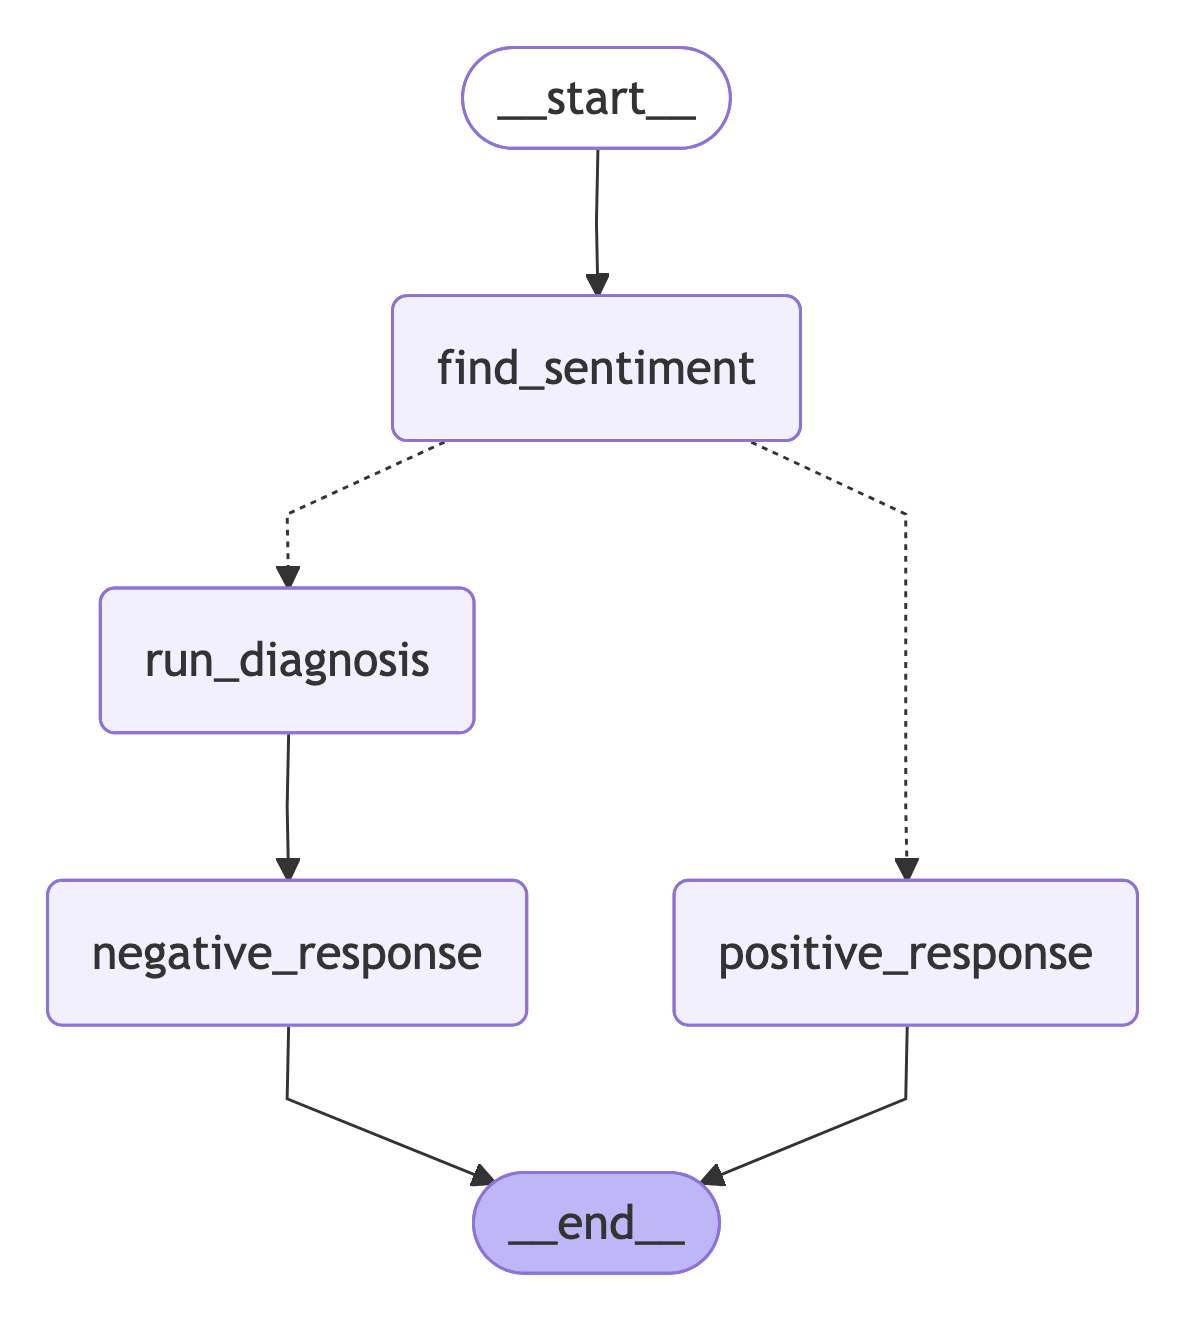

In [13]:
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import Image, display

png_bytes = workflow.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.PYPPETEER
)

display(Image(png_bytes))

In [64]:
initial_state={'review': "The software is good."}
workflow.invoke(initial_state)

{'review': 'The software is good.',
 'sentiment': 'positive',
 'response': "Subject: Thank You for Your Kind Words!\n\nDear [User's Name],\n\nThank you so much for taking the time to share your positive feedback about our software! We’re thrilled to hear that you find it good and that it’s meeting your needs.\n\nYour support means a lot to us, and we’re always looking for ways to improve. If you have any additional thoughts or suggestions, we would love to hear them! Your feedback is invaluable in helping us enhance our product and serve you better.\n\nThanks again for your kind words, and we look forward to continuing to support you!\n\nWarm regards,\n\n[Your Name]  \n[Your Position]  \n[Your Company]  \n[Contact Information]  "}

In [45]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: We're Here to Help with Your Bug Issue\n\nHi [User's Name],\n\nI truly understand how frustrating it can be to encounter a bug, especially when it disrupts your workflow. I want to assure you that we’re here to help you resolve this as quickly as possible.\n\nCould you please provide me with a few more details about the issue? Specifically, any error messages you’re seeing, the steps you took before the bug occurred, and the device or platform you’re using would be incredibly helpful. This information will allow us to diagnose the problem more effectively.\n\nThank you for your patience, and I’m committed to getting this